#**Pré-Processamento de dados**

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np

drive.mount('/content/drive')

df_iris = pd.read_csv("/content/drive/MyDrive/2025/Workshops/Ciência de Dados/Dia 02/iris_sujo.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Visualizar colunas
print(df_iris.info())

# Visualizar cabeçalho do dataset
display(df_iris.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  144 non-null    object 
 1   sepal_width   143 non-null    object 
 2   petal_length  139 non-null    float64
 3   petal_width   143 non-null    float64
 4   species       138 non-null    object 
dtypes: float64(2), object(3)
memory usage: 6.3+ KB
None


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,NaN,1.4,0.2,setosa
2,NaN,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,
4,5.0,3.6,1.4,0.2,setosa


## **Definição**

- É um conjunto de procedimentos aplicado nos dados brutos para prepará-los para outras análises ou tarefas de processamento.
- Suas principais subcategorias são:
  - Limpeza de dados
  - Transformação de dados

## **Motivação**
- Dados do mundo real são "sujos", eles raramente chegam prontos para a análise. Dessa forma, ignorar essa etapa pode gerar conclusões incorretas e decisões baseadas em informações erradas.
- A área apresenta um termo para isso: "lixo entra, lixo sai" (*garbage in, garbage out*)

## **Limpeza de dados**
- Um "dataset sujo" é um conjunto de dados que contém erros, incosistências, colunas repetidas ou valores ausentes. Ex: Uma coluna **cidade** tem "São Paulo", "são paulo", "SP" e "S.Paulo", mas para uma análise, todos deveriam representar a **mesma coisa**. Assim, é necessário realizar uma limpeza no dataframe.

In [ ]:
print("Valores únicos na coluna sepal_width")
# Há valores diferentes do tipo numérico nessa coluna, como 'erro'. Esse é um valor inválido
print(df_iris['sepal_width'].unique())

print("\nValores únicos na coluna species")
# Há valores inconsistentes, como 'setsoa'
print(df_iris['species'].unique())


df_iris.info()

Valores únicos na coluna sepal_width
['3.5' nan '3.2' '3.1' '3.6' '3.9' '3.4' '2.9' '3.7' '3.0' '4.0' '4.4'
 '3.8' '3.3' '4.1' '4.2' '2.3' 'erro' '2.8' '2.4' '2.7' '2.0' '2.2' '2.5'
 '2.6']

Valores únicos na coluna species
['setosa' ' ' nan 'setsoa' 'versicolor' 'virginica']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  144 non-null    object 
 1   sepal_width   143 non-null    object 
 2   petal_length  139 non-null    float64
 3   petal_width   143 non-null    float64
 4   species       138 non-null    object 
dtypes: float64(2), object(3)
memory usage: 6.3+ KB


### **Tratamento de valores inválidos**
- Tratar de valores que não deveriam existir em uma determinada coluna, como texto em colunas numéricas. As funções mais utilizadas são:
- `.pd.to_numeric(arg, errors=)` -> Converte colunas do tipo Object para númericas
  - arg: escalar, lista, tupla...
  - errors:
    - `'raise'` -> valor inválido gera um erro (exceção), opção padrão
    - `'coerce'` -> valor inválido definido como NaN (Not a Number)
    - `'ignore'` -> valor inválido ignorado
- `.pd.to_datetime()` -> Converte colunas Object em um tipo Datetime do Pandas


In [ ]:
# Lista de colunas que deveriam ser numéricas
col_numericas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# errors='coerce' vai forçar textos inválidos (como 'erro') a se tornarem NaN
for col in col_numericas:
  df_iris[col] = pd.to_numeric(df_iris[col], errors='coerce')

print("Informações - Pós-conversão")
df_iris.info()

print("\nUnique 'sepal_width' - Pós-conversão")
print(df_iris['sepal_width'].unique())

Informações - Pós-conversão
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  139 non-null    float64
 1   sepal_width   138 non-null    float64
 2   petal_length  139 non-null    float64
 3   petal_width   143 non-null    float64
 4   species       138 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.3+ KB

Unique 'sepal_width' - Pós-conversão
[3.5 nan 3.2 3.1 3.6 3.9 3.4 2.9 3.7 3.  4.  4.4 3.8 3.3 4.1 4.2 2.3 2.8
 2.4 2.7 2.  2.2 2.5 2.6]


### **Correção de valores Inconsistentes**
O objetivo é padronizar os dados, corrigindo erros de digitação e formatação (como espaços extras). As funções mais utilizadas são:
- `.replace()`: Substitui valores inteiros da célula por outro
- `.str.replace()`: Substitui um padrão ou substring dentro do texto
- `.str.strip()`: Remove espaços em branco do início e do fim do texto
- `.str.lower()` / `.str.upper()`: Converte todo o texto para minúsculas ou maiúsculas, respectivamente

In [ ]:
print("Valores Species antes do .replace()")
print(df_iris['species'].unique())

# Corrigir 'setsoa' para 'setosa' usando .replace()
df_iris['species'] = df_iris['species'].replace('setsoa', 'setosa')

print("\n Species DEPOIS do .replace()")
print(df_iris['species'].unique())

# .str.strip() remove espaços em branco do início e do fim.
df_iris['species'] = df_iris['species'].str.strip()
# O valor ' ' se tornará ''

#Substituir a string vazia ('') por Nulo (np.nan)
df_iris['species'] = df_iris['species'].replace('', np.nan)
print("\n Species DEPOIS de retirar os vazios()")
print(df_iris['species'].unique())


Valores Species antes do .replace()
['setosa' ' ' nan 'setsoa' 'versicolor' 'virginica']

 Species DEPOIS do .replace()
['setosa' ' ' nan 'versicolor' 'virginica']

 Species DEPOIS de retirar os vazios()
['setosa' nan 'versicolor' 'virginica']


In [ ]:
# Exemplo geral: Padronizando uma coluna de CPF

df_cpf = pd.DataFrame({'cpf': [' 123.456.789-10 ', '111222333-44', '999.888.777/00', '12345678913']})

print("Exemplo ANTES da Padronização")
display(df_cpf)

# O regex=False diz que o texto deve ser tratado como literal e não como uma expressão regular
# O regex=True identificaria o '.' como qualquer caracter, e não como um ponto literal
df_cpf['cpf_limpo'] = (df_cpf['cpf']
                          .str.replace('.', '', regex=False)  # Remove pontos
                           .str.replace('-', '', regex=False)  # Remove hífens
                           .str.replace('/', '', regex=False)  # Remove barras
                           .str.strip())                       # Remove espaços

print("\nExemplo DEPOIS da Padronização")
display(df_cpf)

Exemplo ANTES da Padronização


,cpf
0,123.456.789-10
1,111222333-44
2,999.888.777/00
3,12345678913



Exemplo DEPOIS da Padronização


,cpf,cpf_limpo
0,123.456.789-10,12345678910
1,111222333-44,11122233344
2,999.888.777/00,99988877700
3,12345678913,12345678913


### **Tratamento de Valores Ausentes**
Agora, o nosso dataset iris não contém valores inválidos e inconsistentes. Todos os problemas foram convertidos para NaN. Diante disso, veremos duas formas principais de preencher os valores ausentes.
- `.fillna()` -> Preenche os valores ausentes NaN com um valor lógico (como média, mediana ou moda). Uma prática comum é usar a média (`.mean()`) para colunas numéricas. Para colunas categóricas (texto), usamos a moda (`.mode()`).
- `.dropna()` -> Remove todas as linhas que contêm valores NaN. A desvantagem é que em uma base pequena pode faltar dados para análise posterior. Enquanto que a vantagem é trabalhar com dados totalmente reais.
- Obs: Em alguns casos, quando a quantidade de valores ausentes for bem grande em uma coluna é melhor remove-la com `.drop()` do que retirar as linhas.

In [ ]:
# Exemplo 1: Preenchendo colunas númericas com a média

# Conta o número de vazios em todas as colunas
print(f"\nNúmero de ausentes em todas as colunas")
display(df_iris.isnull().sum())

# Conta o número de valores ausentes (NaN) na coluna 'sepal_width'
print(f"\nNaN em 'sepal_width' ANTES: {df_iris['sepal_width'].isna().sum()}")

for col in col_numericas:
    # Calcula a média
    media = df_iris[col].mean()
    # Atribui a média aos valores ausentes da respectiva coluna
    df_iris[col] = df_iris[col].fillna(media)

print(f"NaN em 'sepal_width' DEPOIS: {df_iris['sepal_width'].isna().sum()}")

print(f"\nNúmero de ausentes em todas as colunas")
display(df_iris.isnull().sum())


Número de ausentes em todas as colunas


,0
sepal_length,19
sepal_width,20
petal_length,19
petal_width,15
species,21



NaN em 'sepal_width' ANTES: 20
NaN em 'sepal_width' DEPOIS: 0

Número de ausentes em todas as colunas


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,21


In [ ]:
# Exemplo 2: Preenchendo colunas categóricas com a moda
moda_species = df_iris['species'].mode()[0]  # .mode() retorna uma Series, pegamos o primeiro item [0]

df_iris['species'] = df_iris['species'].fillna(moda_species)

print(f"NaN em 'species' DEPOIS: {df_iris['species'].isna().sum()}")

NaN em 'species' DEPOIS: 0


In [ ]:
print("Verificação final - fillna() ")

print("\nInformações finais")
df_iris.info()

print("\nColuna Species Final")
print(df_iris['species'].unique()) # Deve ter apenas 3 valores limpos

print("\nColuna Sepal Width Final")
print(df_iris['sepal_width'].unique()) # Não deve ter NaN nem 'erro'

Verificação final - fillna() 

Informações finais
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  158 non-null    float64
 1   sepal_width   158 non-null    float64
 2   petal_length  158 non-null    float64
 3   petal_width   158 non-null    float64
 4   species       158 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.3+ KB

Coluna Species Final
['setosa' 'virginica' 'versicolor']

Coluna Sepal Width Final
[3.5        3.06594203 3.2        3.1        3.6        3.9
 3.4        2.9        3.7        3.         4.         4.4
 3.8        3.3        4.1        4.2        2.3        2.8
 2.4        2.7        2.         2.2        2.5        2.6       ]


In [ ]:
# Exemplo 3: Utilizando dropna() para remover as linhas que contêm valores NaN

# Vamos recarregar os dados limpos até a Célula 5 para demonstrar o .dropna()
df_iris_limpo = pd.read_csv("/content/drive/MyDrive/2025/Workshops/Ciência de Dados/Dia 02/iris_sujo.csv")
for col in col_numericas:
    df_iris_limpo[col] = pd.to_numeric(df_iris_limpo[col], errors='coerce')
    df_iris_limpo['species'] = df_iris_limpo['species'].str.strip()
    df_iris_limpo['species'] = df_iris_limpo['species'].replace('', np.nan)
    df_iris_limpo['species'] = df_iris_limpo['species'].replace('setsoa', 'setosa')

print(f'Linhas ANTES do dropna(): {df_iris_limpo.shape[0]}')

df_iris_limpo = df_iris_limpo.dropna()

print(f'\nLinhas DEPOIS do dropna(): {df_iris_limpo.shape[0]}')

Linhas ANTES do dropna(): 158

Linhas DEPOIS do dropna(): 82


### **Exercícios**

In [ ]:
 # DATASET PARA OS EXERCÍCIOS
df_penguins = pd.read_csv("/content/drive/MyDrive/2025/Workshops/Ciência de Dados/Dia 02/penguins_lter_sujo_maior.csv")

# Inspeção inicial
df_penguins.info()

print("\nCinco primeiras linhas:")
display(df_penguins.head())

print(f"\nO número de colunas do dataset é: {df_penguins.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            722 non-null    object 
 1   Sample Number        722 non-null    int64  
 2   Species              722 non-null    object 
 3   Region               722 non-null    object 
 4   Island               722 non-null    object 
 5   Stage                722 non-null    object 
 6   Individual ID        722 non-null    object 
 7   Clutch Completion    722 non-null    object 
 8   Date Egg             722 non-null    object 
 9   Culmen Length (mm)   686 non-null    float64
 10  Culmen Depth (mm)    718 non-null    float64
 11  Flipper Length (mm)  692 non-null    float64
 12  Body Mass (g)        680 non-null    object 
 13  Sex                  702 non-null    object 
 14  Delta 15 N (o/oo)    694 non-null    float64
 15  Delta 13 C (o/oo)    696 non-null    flo

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments,Gender,Islnd
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,50.094120,18.7,182.612585,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.,Male,Torgersen
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,60.552601,17.4,195.765806,3800.0,FEMALE,8.94956,-24.69454,NaN,Female,Torgersen
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,39.368592,18.0,NaN,3250.0,FEMALE,8.36821,-25.33302,NaN,Female,Torgersen
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.,NaN,Torgersen
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,29.775594,19.3,189.944014,3450.0,FEMALE,8.76651,-25.32426,NaN,NaN,Torgersen



O número de colunas do dataset é: 19


**0. Reflita sobre o que representa cada coluna desse dataset representa e escreva uma breve explicação.**

- `studyName`: O nome do estudo ou pesquisa que coletou os dados.
- `Sample Number`: Um número de identificação para a amostra.
- `Species`: A espécie do pinguim.
- `Region`: A região geográfica onde a observação foi feita.
- `Island`: A ilha específica onde o pinguim foi encontrado.
- `Stage`: O estágio de vida do pinguim (ex: Adulto, Filhote).
- `Individual ID`: Um código único para identificar um pinguim específico.
- `Clutch Completion`: Informa se a ninhada de ovos foi concluída (Sim ou Não).
- `Date Egg`: A data em que o ovo foi observado ou coletado.
- `Culmen Length (mm)`: O comprimento do bico do pinguim, em milímetros.
- `Culmen Depth (mm)`: A profundidade (altura) do bico do pinguim, em milímetros.
- `Flipper Length (mm`): O comprimento da nadadeira do pinguim, em milímetros.
- `Body Mass (g)`: A massa corporal (peso) do pinguim, em gramas.
- `Sex`: O sexo biológico do pinguim (Macho ou Fêmea).
- `Delta 15 N (o/oo)`: Uma medida de isótopo de Nitrogênio (usada para análise de dieta).
- `Delta 13 C (o/oo)`: Uma medida de isótopo de Carbono (usada para análise de dieta).
- `Comments`: Anotações ou comentários adicionais sobre a amostra.
- `Gender`: O sexo biológico do pinguim (Macho ou Fêmea).
- `Islnd`: A ilha específica onde o pinguim foi encontrado.

In [ ]:
# Trocar o nome das colunas para o padrão snake_case
# Dicionário com os nomes antigos e novos
mapa_nomes = {
    'studyName': 'study_name',
    'Sample Number': 'sample_number',
    'Species': 'species',
    'Region': 'region',
    'Island': 'island',
    'Stage': 'stage',
    'Individual ID': 'individual_id',
    'Clutch Completion': 'clutch_completion',
    'Date Egg': 'date_egg',
    'Culmen Length (mm)': 'culmen_length_mm',
    'Culmen Depth (mm)': 'culmen_depth_mm',
    'Flipper Length (mm)': 'flipper_length_mm',
    'Body Mass (g)': 'body_mass_g',
    'Sex': 'sex',
    'Delta 15 N (o/oo)': 'delta_15_n_ooo',
    'Comments' : 'comments',
    'Gender' : 'gender',
    'Islnd' : 'islnd',
    'Delta 13 C (o/oo)': 'delta_13_c_ooo'
}

# Renomear as colunas
df_penguins = df_penguins.rename(columns=mapa_nomes)

print(df_penguins.columns)

Index(['study_name', 'sample_number', 'species', 'region', 'island', 'stage',
       'individual_id', 'clutch_completion', 'date_egg', 'culmen_length_mm',
       'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex',
       'delta_15_n_ooo', 'delta_13_c_ooo', 'comments', 'gender', 'islnd'],
      dtype='object')


**1. Verifique e retire as colunas que são inúteis para a análise ou que são duplicadas/redudantes**

**2. Investigue o dataset com `.info()` para encontrar colunas de medidas que estão como object. Use `.pd.to_numeric()` com `errors='coerce`' para forçar a conversão, transformando qualquer texto inválido em `NaN`.**

**3. A coluna `sex` apresenta valores inconsistentes, investigue os valores únicos e padronize a coluna, isto é, deixe todos os valores como `MALE` ou `FEMALE`.**

**4. Preencha todos os valores ausentes (`NaN`) Aplique a média da coluna para os dados numéricos (medidas) e a moda (valor mais frequente) para os dados categóricos (texto). Dica: Primeiro visualize a quantidade de valores ausentes nas colunas**

## **Transformação de dados**
Etapa de conversão dos dados (que já estão limpos e integrados) em formatos adequados para análise

In [ ]:
# carregar um dataset limpo
df_iris = pd.read_csv("/content/drive/MyDrive/2025/Workshops/Ciência de Dados/Dia 02/iris.csv")

display(df_iris.head())
df_iris.info()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### **Criação de novos recursos**
Consiste na criação de variáveis que representam a **interação** entre duas ou mais variáveis existentes. Além disso, novos recursos podem surgir a partir da **extração** de informações relevantes de variáveis complexas, como decompor datas em dias, meses e anos.


In [ ]:
# Multiplicamos duas colunas existentes para criar uma nova
df_iris['petal_area'] = df_iris['petal_length'] * df_iris['petal_width']

print("\n--- HEAD (Com a nova coluna 'petal_area') ---")
print(df_iris.head())


--- HEAD (Com a nova coluna 'petal_area') ---
   sepal_length  sepal_width  petal_length  petal_width species  petal_area
0           5.1          3.5           1.4          0.2  setosa        0.28
1           4.9          3.0           1.4          0.2  setosa        0.28
2           4.7          3.2           1.3          0.2  setosa        0.26
3           4.6          3.1           1.5          0.2  setosa        0.30
4           5.0          3.6           1.4          0.2  setosa        0.28


### **Discretização dos dados**
A Discretização, também conhecida como *binning*, é usada para **transformar valores contínuos em discretos**, ou seja, em categorias. Essa técnica é importante para reduzir possíveis valores extremos e flutuações, ajudando assim, em alguns modelos de aprendizado de máquina.
- `.cut(col, bins=, labels=, right=)`: Classifica os valores dos dados em categorias

In [ ]:
# Definição dos limites das faixas
intervalos = [0, 2, 5, 10] # 0-2(Curta), 2-5 (Média), 5-10 (Longa)

# Definição dos nomes das faixas
categorias = ['Curta', 'Média', 'Longa']

# Categorizar os dados
df_iris['petal_length_category'] = pd.cut(df_iris['petal_length'], bins=intervalos, labels=categorias)


print(df_iris[['petal_length', 'petal_length_category', 'species']].head())


   petal_length petal_length_category species
0           1.4                 Curta  setosa
1           1.4                 Curta  setosa
2           1.3                 Curta  setosa
3           1.5                 Curta  setosa
4           1.4                 Curta  setosa


### **Encoding de variáveis categóricas**
Os modelos matemáticos são baseados em matemática e não conseguem processar valores de texto. Para que os algoritmos possam utilizar essas informações, precisamos convertê-las em um formato numérico que o modelo possa entender. Esse processo é chamado de *Encoding*. As duas abordagens mais comuns são:
- **One-Hot Encoding:** Converter variáveis categóricas em uma forma que pode ser fornecida a modelos de machine learning, criando uma coluna para cada categoria. Cada uma dessas novas categorias atua como uma "bandeira" (flag) binária. Para uma determinada linha, a coluna correspondente à sua categoria original recebe o valor True (1) por padrão, enquanto que as demais recebem o valor False (0).
- **Label Encoding:** Atribuir um número inteiro a cada categoria, útil para algoritmos que podem trabalhar diretamente com números.

In [ ]:
# Aplicação do One-Hot Encoding

# .get_dummies() cria novas colunas para cada categoria
df_iris_encoded = pd.get_dummies(df_iris, columns=['species'], dtype=int)
# dtype= indica como deve ser feito a flag nas colunas, por padrão é do tipo bool
print(df_iris_encoded.head())

   sepal_length  sepal_width  petal_length  petal_width  petal_area  \
0           5.1          3.5           1.4          0.2        0.28   
1           4.9          3.0           1.4          0.2        0.28   
2           4.7          3.2           1.3          0.2        0.26   
3           4.6          3.1           1.5          0.2        0.30   
4           5.0          3.6           1.4          0.2        0.28   

  petal_length_category  species_setosa  species_versicolor  species_virginica  
0                 Curta               1                   0                  0  
1                 Curta               1                   0                  0  
2                 Curta               1                   0                  0  
3                 Curta               1                   0                  0  
4                 Curta               1                   0                  0  


### **Normalização**
Etapa de ajuste das colunas numéricas para que todos tenham um peso semelhante no caso dos dados serem utilizados em modelos de aprendizado de máquina.
- **Min-Max Scaling:** Coloca todos os valores de uma coluna em uma escala específica, geralmente de 0 a 1.

In [ ]:
# Aplicação do Min-Max Scaling
# Fórmula: (valor - min) / (max - min)

min = df_iris['sepal_length'].min()
max = df_iris['sepal_length'].max()

df_iris['sepal_length_normalizada'] = (df_iris['sepal_length'] - min) / (max - min)

print(df_iris[['sepal_length', 'sepal_length_normalizada']].head())


   sepal_length  sepal_length_normalizada
0           5.1                  0.222222
1           4.9                  0.166667
2           4.7                  0.111111
3           4.6                  0.083333
4           5.0                  0.194444


### **Exercícios**

**1. A coluna `body_mass_g` está em gramas. Crie uma nova coluna chamada `body_mass_kg` que contenha a massa corporal convertida para quilogramas**


**2. Modelos de Aprendizado de Máquina não aprendem texto, use `.pd.get_dummies()` para aplicar One-Hot Encoding nas colunas `island` e `sex`**

#**Extração de métricas de dados**

## **Definição**

- É o processo de coletar, calcular e analisar informações quantificáveis a partir de um conjunto de dados para resumir e interpretar as principais características desses dados.
- As métricas podem ser categorizadas em:
  - Métricas de tendência central (ex: média, mediana)
  - Métricas de dispersão (ex: desvio padrão, variância)
  - Métricas de contagem (ex: frequência de valores únicos)
  - Métricas de agregação (ex: média ou soma de grupos)

- Essas métricas fornecem uma base sólida para a tomada de decisões e construção de modelos explicativos ou preditivos.

## **Motivação**

- Compreensão dos dados.
- Auxilia na identificação de tendências e padrões.
- Serve como apoio à tomada de decisões.
- Fundamentação para Modelagem Estatística e Machine Learning.
- Detecção de _Outliers_ e Anomalias.

## Estatísticas Descritivas
- Ajudam a resumir um conjunto de dados, fornecendo informações sobre a sua distribuição, centralidade e dispersão. O pandas oferece várias operações para obter essas métricas.


### **Método describe()**
- Fornece um resumo estatístico das colunas numéricas do DataFrame, como média, mediana, desvio padrão, valores mínimo e máximo, e percentis (25%, 50%, 75%).

In [ ]:
import pandas as pd

# carregar dados
df_iris = pd.read_csv("/content/drive/MyDrive/2025/Workshops/Ciência de Dados/Dia 02/iris.csv")

# resumo estatístico de todas as colunas numéricas
resumo = df_iris.describe()
print(resumo)

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


Além do `describe()`, podemos calcular métricas adicionais diretamente:

### **Média**

- É a soma dos valores dividida pelo número de valores.


In [ ]:
media = df_iris['sepal_length'].mean()
print(f'Média: {media}')

Média: 5.843333333333334


### **Mediana**
- É o valor que separa os dados em duas metades.

In [ ]:
mediana = df_iris['sepal_length'].median()
print(f'Mediana: {mediana}')

Mediana: 5.8


### **Desvio Padrão**
- Mede a dispersão dos dados em relação à média.

In [ ]:
desvio_padrao = df_iris['petal_width'].std()
print(f'Desvio Padrão: {desvio_padrao}')

Desvio Padrão: 0.7631607417008414


### **Variância**
- É uma medida estatística que indica o quanto os valores de um conjunto de ados se afastam da média. Ou seja, ela mostra a dispersão dos dados.
- Quanto maior a variância, mais espalhados estão os valores.
- Quanto menor a variância, mais próximos da média estão os valores.

In [ ]:
variancia =  df_iris['sepal_width'].var()
print(f'Variância: {variancia:.2f}')

Variância: 0.19


### **Moda**
- É o valor que mais aparece em uma coluna.

In [ ]:
moda = df_iris['petal_length'].mode()
print(f'Moda: {moda}')

Moda: 0    1.5
Name: petal_length, dtype: float64


### **Matriz de Correlação**

A matriz de correlação é uma ferramenta estatística que mostra o grau de relação linear entre variáveis numéricas.

Cada valor da matriz varia entre -1.0 e +1.0:
- +1.0: correlação positiva perfeita (as duas variáveis aumentam juntas)
- -1.0: correlação negativa perfeita (uma aumenta e outra diminui)
- 0: sem correlação linear

Com o pandas, podemos gerar essa matriz facilmente e utilizá-la para identificar variáveis que têm relações fortes (positivas ou negativas), o que é muito útil em análises exploratórias e modelagem preditiva.

In [ ]:
# Exemplo prático

corr_matrix = df_iris.corr(numeric_only=True)

# Exibindo a matriz
corr_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


## Contagens e Distribuições
- Esses métodos ajudam a entender como os dados estão distribuídos em termos de frequência e categorias.

### **Contagem de valores únicos (value_counts())**
- O método `value_counts()` conta quantas vezes cada valor único aparece em uma coluna, sendo muito útil para variáveis categóricas.
- Também pode ser aplicado a variáveis numéricas, usando o parâmetro bins, que divide os valores em intervalos de faixas.

In [ ]:
# Exemplo 1
contagem_1 = df_iris['sepal_length'].value_counts()
print(contagem_1)

# Exemplo 2
contagem_2 = df_iris["petal_length"].value_counts(bins=5, sort=False)
print('\nDistribuição dos comprimentos das pétalas (petal_length):\n', contagem_2, sep='')

# O parâmetro 'sort=False' mantém a ordem crescente dos intervalos, o que facilita a leitura
# da distribuição

sepal_length
5.0    10
6.3     9
5.1     9
6.7     8
5.7     8
6.4     7
5.5     7
5.8     7
4.9     6
6.0     6
5.4     6
5.6     6
6.1     6
6.5     5
4.8     5
7.7     4
6.9     4
4.6     4
5.2     4
6.2     4
4.4     3
7.2     3
5.9     3
6.8     3
4.7     2
6.6     2
4.3     1
7.0     1
5.3     1
4.5     1
7.1     1
7.3     1
7.6     1
7.4     1
7.9     1
Name: count, dtype: int64

Distribuição dos comprimentos das pétalas (petal_length):
(0.993, 2.18]    50
(2.18, 3.36]      3
(3.36, 4.54]     34
(4.54, 5.72]     47
(5.72, 6.9]      16
Name: count, dtype: int64


- Isso indica que o valor '5.0' aparece 10 vezes, '6.3' 9 vezes, e assim por diante.

### **Distribuição com Histograma (hist())**
- O histograma mostra a distribuição de uma variável numérica dividida em intervalos. O pandas possui o método `hist()`, que gera um gráfico.

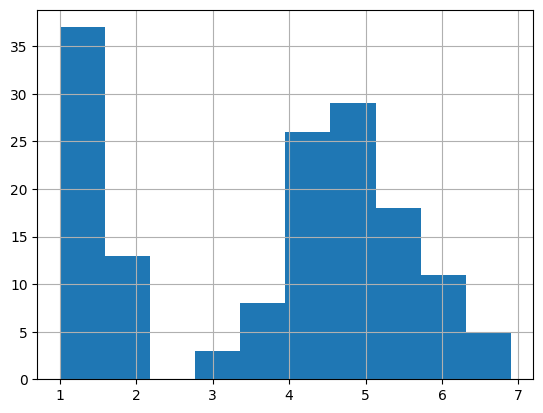

In [ ]:
import matplotlib.pyplot as plt

# o parâmetro "bins" define em quantos intervalos (faixas numéricas) os dados serão divididos
# no eixo X do histograma. Cada intervalo mostra quantos valores "caem" nele
df_iris['petal_length'].hist(bins=10)
plt.show()

### **Distribuição Percentual (value_counts(normalize=True))**
- Podemos calcular a distribuição percentual dos valores em uma coluna  utilizando o argumento `normalize=True` em `value_counts()`.

In [ ]:
distribuicao_percentual = df_iris['petal_width'].value_counts(normalize=True)
print(distribuicao_percentual)

petal_width
0.2    0.186667
1.3    0.086667
1.5    0.080000
1.8    0.080000
1.4    0.053333
2.3    0.053333
0.4    0.046667
1.0    0.046667
0.3    0.046667
0.1    0.040000
2.1    0.040000
2.0    0.040000
1.2    0.033333
1.9    0.033333
1.6    0.026667
2.5    0.020000
2.2    0.020000
1.1    0.020000
2.4    0.020000
1.7    0.013333
0.6    0.006667
0.5    0.006667
Name: proportion, dtype: float64


- Esse código mostra a proporção de cada valor, como um número decimal (por exemplo, 0.50 significa 50%).

### **Exercícios**

Utilizando o dataset dos pinguins limpo anteriormente, extraia e interprete as principais métricas descritivas das variáveis numéricas.
O objetivo é compreender as medidas de tendência central, dispersão, amplitude e correlação.

- Exiba um resumo geral com ```describe()```.

- Calcule a média, mediana e moda da coluna body_mass_g.

- Calcule a variância, desvio padrão, mínimo, máximo e amplitude da coluna flipper_length_mm.

- Gere a matriz de correlação entre as variáveis numéricas.

## **Agrupamento de Dados**
- Permite segmentar os dados por uma ou mais colunas e aplicar funções agregadas (como soma e média) a cada grupo.

### **Agrupamento com groupby()**
O método groupby() é utilizado para dividir os dados em grupos com base em uma ou mais colunas e aplicar operações agregadas sobre cada grupo.

\* Operações/funções agregadas são funções que resumem um conjunto de valores em um único resultado. Elas são usadas para calcular métricas como média, soma, mínimo, máximo, contagem, entre outras, geralmente após o agrupamento de dados

### **Exemplo de agrupamento simples**



In [ ]:
agrupado = df_iris.groupby('species')['petal_width'].mean()
print(agrupado)

species
setosa        0.244
versicolor    1.326
virginica     2.026
Name: petal_width, dtype: float64


No código acima, os dados são agrupados pela coluna 'coluna_categoria' e a média da 'coluna_numerica' é calculada para cada grupo.

### **Exemplo de Agrupamento com Múltiplas Funções**

In [ ]:
agrupado = df_iris.groupby('species')['sepal_length'].agg(['mean', 'sum', 'count'])
print(agrupado)

             mean    sum  count
species                        
setosa      5.006  250.3     50
versicolor  5.936  296.8     50
virginica   6.588  329.4     50


O código acima retorna a média, a soma e a contagem dos valores da coluna numérica, para cada categoria.

### **Agrupamento por Múltiplas Colunas**
- É possível também agrupar por mais de uma coluna. Isso cria grupos baseados na combinação dessas colunas.

In [ ]:
agrupado_multiplas = df_iris.groupby(['species', 'sepal_length']).sum()
print(agrupado_multiplas)


                         sepal_width  petal_length  petal_width
species    sepal_length                                        
setosa     4.3                   3.0           1.1          0.1
           4.4                   9.1           4.0          0.6
           4.5                   2.3           1.3          0.3
           4.6                  13.3           5.3          0.9
           4.7                   6.4           2.9          0.4
           4.8                  15.9           7.9          1.0
           4.9                  12.3           5.9          0.5
           5.0                  26.9          11.6          2.3
           5.1                  28.8          12.5          2.5
           5.2                  11.0           4.4          0.5
           5.3                   3.7           1.5          0.2
           5.4                  18.3           7.7          1.6
           5.5                   7.7           2.7          0.4
           5.7                   8.2    

Isso vai agrupar os dados por ambas as colunas e calcular a soma dos valores numéricos para cada combinação de categorias.

### **Exercícios**

Utilize o dataset dos pinguins para explorar as contagens de categorias e a distribuição de valores numéricos.

- Conte quantos pinguins existem de cada espécie.

- Conte quantos pinguins existem em cada região.

- Calcule a média de massa corporal por espécie.

- Gere a distribuição de frequências da variável body_mass_g dividindo-a em intervalos.

- Analise a proporção de pinguins machos e fêmeas a partir das colunas sex_FEMALE e sex_MALE.

# **Matplotlib**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_iris = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")
df_penguins = pd.read_csv('/content/drive/MyDrive/2025/Workshops/Ciência de Dados/Dia 02/penguins_limpo.csv')

## **Definição**
* É uma biblioteca fundamental para a criação de visualizações de dados estáticas, animadas e interativas em Python.
* [Acesse a documentação](https://matplotlib.org/stable)
* [Acesse o repositório no GitHub](https://github.com/matplotlib/matplotlib)

## **Motivação**
* Em ciência de dados, um bom gráfico pode revelar padrões, tendências e *outliers* que são impossíveis de ver em uma tabela de números.
* Um dos principais objetivos é transformar a análise de dados em algo visual e intuitivo, facilitando a comunicação dos resultados.

## **Principais tipos de gráficos**
* Existem [diversos tipos de gráficos](https://matplotlib.org/stable/plot_types/index.html) oferecidos pelo Matplotlib, cada um com sua especificidade e com objetivos de uso diferentes.
* Nesse workshop, aprenderemos alguns deles, como gráficos de linhas, histogramas, barras e dispersão.

### **Linhas**


* Quando usar?
  * Para visualizar a evolução de uma variável ao longo do tempo ou de uma sequência contínua.
    * Exemplos: evolução do faturamento mensal de uma empresa em um ano; temperatura média diária de uma cidade em um mês; altura de uma criança ao longo do crescimento.
  * Para identificar padrões de picos ou quedas.
    * Exemplos: número de acessos a um site por hora; desempenho de alunos em disciplinas de um semestre; número de pacientes em uma unidade de saúde ao longo do dia.
  * Algumas métricas que "combinam" com esse estilo de gráfico são:
    * `mean()` - média: tendência central dos dados;
    * `median()` - mediana: valor central sem viés;
    * `std()` - desvio padrão: grau de dispersão dos dados.

* Como usar?
  ```
  plt.plot(x, y)
  ```
  * eixos `x` | `y` : lista, Series, ...
    * Ambos os eixos devem ser do mesmo tamanho.
  * Você pode chamar `plt.plot()` diversas vezes para adicionar várias linhas ao mesmo gráfico.

#### **Exemplo prático!**

1. Utilize o gráfico de linhas para demonstrar a média do comprimento e da largura das sépalas e das pétalas, para cada espécie.

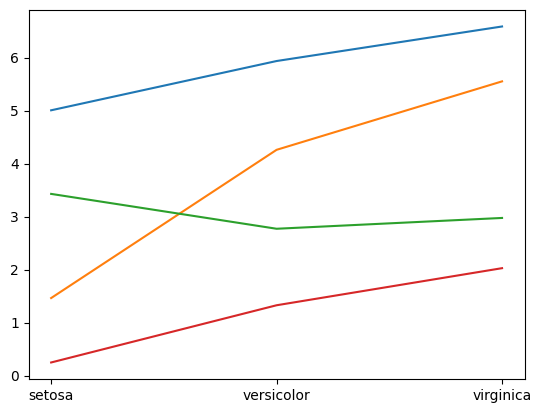

In [ ]:
# Solução 1:

# Cálculos de comprimentos e larguras médios
mean_sepal_length = df_iris.groupby('species')['sepal_length'].mean()
mean_petal_length = df_iris.groupby('species')['petal_length'].mean()
mean_sepal_width = df_iris.groupby('species')['sepal_width'].mean()
mean_petal_width = df_iris.groupby('species')['petal_width'].mean()

# Deve haver uma instância para cada linha de comprimento e largura
plt.plot(mean_sepal_length.index, mean_sepal_length)
plt.plot(mean_petal_length.index, mean_petal_length)
plt.plot(mean_sepal_width.index, mean_sepal_width)
plt.plot(mean_petal_width.index, mean_petal_width)

plt.show()

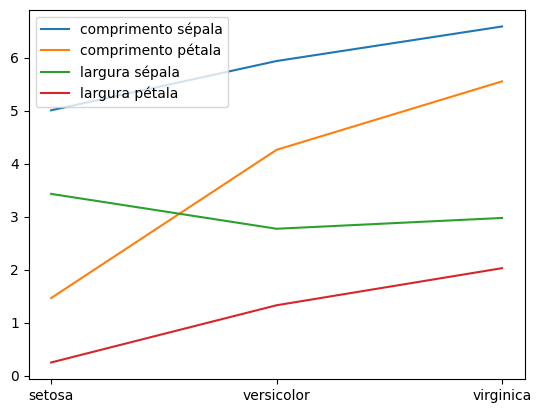

In [ ]:
# Solução 2:

# A primeira solução nos resultou um gráfico de linhas, mas não sabemos o que cada uma delas representa de fato.
# Para deixar o nosso gráfico mais legível, podemos utilizar rótulos/legendas que servem como descrições.

mean_sepal_length = df_iris.groupby('species')['sepal_length'].mean()
mean_petal_length = df_iris.groupby('species')['petal_length'].mean()
mean_sepal_width = df_iris.groupby('species')['sepal_width'].mean()
mean_petal_width = df_iris.groupby('species')['petal_width'].mean()

# Adicionamos o campo label='' no método plt.plot()
plt.plot(mean_sepal_length.index, mean_sepal_length, label='comprimento sépala')
plt.plot(mean_petal_length.index, mean_petal_length, label='comprimento pétala')
plt.plot(mean_sepal_width.index, mean_sepal_width, label='largura sépala')
plt.plot(mean_petal_width.index, mean_petal_width, label='largura pétala')

plt.legend()  # permite a exibição das labels definidas

plt.show()

#### **Exercício**

1. Utilize o gráfico de linhas para demonstrar as medianas do comprimento e da profundidade do bico e do comprimento da nadadeira, para cada espécie.
- Dica: se baseie na Solução 2 do Exemplo Prático 1.



### **Histograma**

* Quando usar?
  * Para entender a distribuição de uma única variável numérica. Permite identificar tendências (picos ou quedas).
    * Exemplos: distribuição das idados dos alunos em uma turma; frequência de vendas de um produto por quantidade.

* Como usar?
  ```
  plt.hist(x, bins)
  ```
  * eixo `x` : list
    * Dados que serão plotados.
  * `bins` : int | list
    * Argumento opcional.
    * Por padrão, vale 10.
    * O histograma divide os dados em intervalos e conta quantas observações caem em cada caixa.

#### **Exemplo prático!**

2. Utilize um histograma para demonstrar a distribuição de comprimento das pétalas.

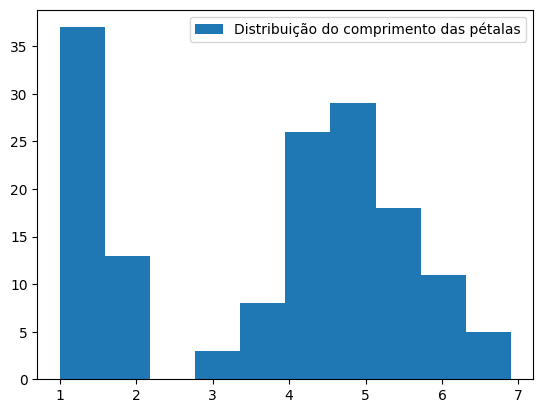

In [ ]:
# Solução 1:

plt.hist(df_iris['petal_length'], label='Distribuição do comprimento das pétalas')

plt.legend()  # ativação da 'label' definida

plt.show()

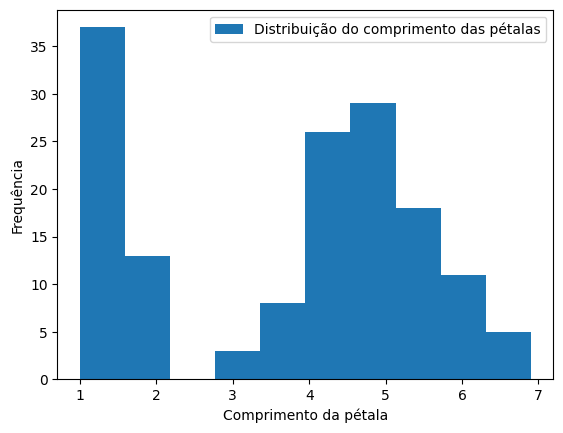

In [ ]:
# Solução 2:

# Apesar da label já nos auxiliar no entendimento do gráfico, ainda podemos incrementá-lo!
# Os métodos .xlabel e .ylabel nos permitem adicionar descrições para os eixos x e y, respectivamente.

plt.hist(df_iris['petal_length'], label='Distribuição do comprimento das pétalas')

# Adiciona descrições dos eixos (métodos válidos para qualquer tipo de gráfico)

plt.xlabel('Comprimento da pétala')
plt.ylabel('Frequência')

plt.legend()  # ativação da 'label' definida

plt.show()

#### **Exercício**

2. Utilize um histograma para demonstrar a distribuição de massa corporal em quilogramas.
- Dica: se baseie na Solução 2 do Exemplo Prático 2.

### **Barras**

* Quando usar?
  * Para comparar valores entre diferentes categorias.
    * Exemplos: resultado do value_counts; salário por faixa etária; quantidade de produção de um produto de uma empresa por ano.
  * Para ranqueamentos, quando a posição de um item na lista é tão ou mais importante que seu valor em si.
    * Exemplos: tabelas de ligas de esporte; músicas mais escutadas; países mais ricos do mundo.
  * Algumas métricas que "combinam" com esse estilo de gráfico são:
    * `mean()` - média;
    * `count()` - contagem de valores: quantidade de amostras por grupo;
    * `sum()` - soma total.

* Como usar?
  ```
  # Barras verticais
  plt.bar(x, height)

  # Barras horizontais
  plt.barh(y, width)
  ```
  * eixos `x` | `y` : float | list
    * Etiquetas que "explicam" cada barra.
  * `height` (altura) | `width` (largura): float | list
    * Valores do gráfico, indicam a altura/largura das barras.

#### **Exemplo prático!**

3. Utilize um gráfico de barras verticais para mostrar a quantidade de amostras por espécie.

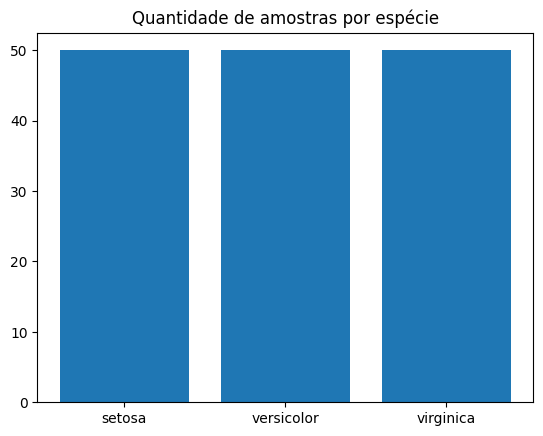

In [ ]:
qtde_amostras = df_iris['species'].value_counts()

especies = qtde_amostras.index

plt.bar(especies, qtde_amostras)

# Adiciona título ao gráfico (método válido para qualquer tipo de gráfico)

plt.title("Quantidade de amostras por espécie")

plt.show()

#### **Exercício**

3. Utilize um gráfico de barras horizontais para mostrar a quantidade de amostras por espécie.

### **Dispersão**

* Quando usar?
  * Para visualizar a relação entre duas variáveis numéricas, como correlações ou padrões de agrupamento.
    * Exemplo: visualizar tempo de execução em função do tamanho da entrada;horas de sono *versus* nível de estresse; número de postagens *versus* engajamento.

* Como interpretar?
  * **Linha ascendente**: indica correlação positiva, ou seja, se `x` aumenta, `y` tende a aumentar.
  * **Linha descendente**: indica correlação negativa, ou seja, se `x` aumenta, `y` tende a diminuir.
  * Se os pontos parecem espalhados aleatoriamente, não é possível identificar correlação somente pela observação do gráfico.
  * Se os pontos estão concentrados em diferentes regiões do gráfico, pode indicar grupos distintos (exemplo: diferentes espécies de flores).
  * Pontos "isolados" ou muito distantes dos demais podem indicar *outliers* (exceções) ou erros no *DataFrame*.

* Como usar?
  ```
  plt.scatter(x, y)
  ```
  * eixos `x` | `y` : list | Series
    * Valores das variáveis.
    * Cada ponto no gráfico representa uma linha do *DataFrame*.

#### **Exemplo prático!**
4. Utilize um gráfico de dispersão para mostrar se há correlação entre o comprimento e a largura da pétala, sem distinção de espécies.

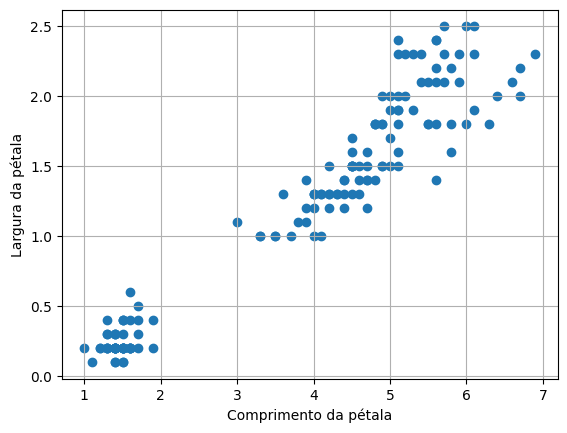

In [ ]:
plt.scatter(df_iris['petal_length'], df_iris['petal_width'])
plt.xlabel('Comprimento da pétala')
plt.ylabel('Largura da pétala')

# Adiciona linhas de grade verticais e horizontais (método válido para qualquer tipo de gráfico)

plt.grid(True)

plt.show()

# Interpretação do gráfico para análise de correlação:

# Nesse exemplo, cada "bolinha" no gráfico representa uma flor do DataFrame.

# Pela presença de uma linha ascendente, podemos perceber uma correlação positiva:
#   - À medida que o comprimento da pétala aumenta, a largura também aumenta.
#   - Isso indica que flores com pétalas mais compridas tendem a também ser mais largas.

# Também podemos perceber a formação de dois grupos:
#   - Canto inferior esquerdo: comprimento entre 1.0-2.0; largura entre 0.0-0.6.
#   - Meio e canto superior direito: comprimento > 3; largura > 1.
#   Obs.: não há nenhum ponto muito fora da tendência geral.

#### **Exercício**

4. Utilize um gráfico de dispersão para mostrar se há correlação entre o comprimento da nadadeira (mm) e a massa corporal dos pinguins (kg), sem distinção de espécies.

## **Customização do gráfico**

### **Tamanho da imagem**

* Para controlar o tamanho da imagem, podemos utilizar o método:

  `plt.figure(figsize=(largura, altura))`

* Os argumentos `largura` e `altura` são em polegadas.

### **Cores**

* Métodos dos gráficos, como `plt.plot()`, `plt.bar()`, `plt.scatter()`, aceitam o argumento `color="nome_da_cor"`, exemplos:
  * Nome em inglês: `color="purple"`;
  * Código hexadecimal: `color="#6914d9"`;
  * Código RGB (entre 0 e 1, precisa dividir por 255): `color=(105/255, 20/255, 217/255)`.

### **Estilo de linha de grade**

* `plt.grid(True)`: ativa as linhas de grade.
* `linestyle`: estilo da linha da grade, variando entre:
  * " - " (sólida);
  * " -- " (tracejada);
  * " : " (pontilhada).
* `linewidth`: espessura da linha da grade.

* Exemplo de uso:
  
  `plt.gride(True, color='gray', linestyle='--', linewidth=0.5)`

### **Marcadores**

* `marker`: define o formato dos pontos em gráficos de linha (como já visto: `plt.plot()`), variando entre:
  * "o" (círculo);
  * "s" (quadrado);
  * "^" (triângulo);
  * "x" (x).
* `markersize`: tamanho do marcador.
* `markerfacecolor`: cor interna do marcador.
  * Segue o mesmo padrão de argumento que o método `color`.
* `markeredgecolor`: cor da borda do marcador.
  * Segue o mesmo padrão de argumento que o método `color`.

### **Legendas e título**

* `plt.title('Título do gráfico')`
* `plt.xlabel('Legenda para o eixo x')`
* `plt.ylabel('Legenda para o eixo y')`
* `fontsize`: controla o tamanho da fonte do título ou das labels.
* `label='descrição da linha'`: define um nome para uma linha ou série, usado nos métodos `plt.plot()`, `plt.bar()`, etc.

* Exemplos de uso:

  `plt.plot(meses, qtde, label='Vendas 2025')`

  `plt.title('Vendas mensais', fontsize=16)`
  
  `plt.xlabel('Mês', fontsize=12)`
  
  `plt.ylabel('Quantidade', fontsize=12)`
  
  `plt.legend()`

## **Exportar gráfico para um arquivo**

`plt.savefig("nome_do_arquivo.extensao")`
* Principais formatos suportados: .png, .jpg, .pdf, .svg